In [1]:
#Import Libraries
import pandas as pd
import numpy as np
from faker import Faker
import random
import sqlite3

In [2]:
#Generate Users Table
fake = Faker()

n_users = 1000

users = pd.DataFrame({
    "user_id": range(1, n_users+1),
    "device": np.random.choice(["mobile", "desktop"], n_users),
    "source": np.random.choice(["organic", "ads", "social"], n_users)
})

users.head()

,user_id,device,source
0,1,desktop,organic
1,2,mobile,organic
2,3,mobile,social
3,4,mobile,social
4,5,desktop,social


In [3]:
#Generate Sessions
sessions = pd.DataFrame({
    "session_id": range(1, n_users+1),
    "user_id": users["user_id"],
    "session_date": pd.date_range(start="2024-01-01", periods=n_users)
})

sessions.head()

,session_id,user_id,session_date
0,1,1,2024-01-01
1,2,2,2024-01-02
2,3,3,2024-01-03
3,4,4,2024-01-04
4,5,5,2024-01-05


In [4]:
#Generate Events
events = []

for i in sessions["session_id"]:
    # Step 1: everyone browses
    events.append([i, "browse"])
    
    # Step 2: 70% go to cart
    if random.random() < 0.7:
        events.append([i, "add_to_cart"])
        
        # Step 3: 50% go to checkout
        if random.random() < 0.5:
            events.append([i, "checkout"])

events_df = pd.DataFrame(events, columns=["session_id", "event_type"])

events_df.head()

,session_id,event_type
0,1,browse
1,1,add_to_cart
2,2,browse
3,2,add_to_cart
4,2,checkout


In [5]:
#Generate Orders
orders = []

for i in sessions["session_id"]:
    # 40% conversion rate
    if random.random() < 0.4:
        orders.append([i, random.randint(100, 1000), "completed"])

orders_df = pd.DataFrame(orders, columns=["session_id", "revenue", "status"])

orders_df.head()

,session_id,revenue,status
0,2,827,completed
1,7,380,completed
2,9,226,completed
3,12,409,completed
4,14,127,completed


In [6]:
#Connect to sql
conn = sqlite3.connect("funnel.db")

In [7]:
#Pushing data to sql tables
users.to_sql("users", conn, if_exists="replace", index=False)
sessions.to_sql("sessions", conn, if_exists="replace", index=False)
events_df.to_sql("events", conn, if_exists="replace", index=False)
orders_df.to_sql("orders", conn, if_exists="replace", index=False)

360

In [8]:
#Total Sessions vs Orders
query = """
SELECT 
    COUNT(DISTINCT s.session_id) AS total_sessions,
    COUNT(DISTINCT o.session_id) AS total_orders
FROM sessions s
LEFT JOIN orders o 
ON s.session_id = o.session_id;
"""

pd.read_sql(query, conn)

,total_sessions,total_orders
0,1000,360


In [9]:
#Conversion Rate
query = """
SELECT 
    COUNT(DISTINCT o.session_id) * 1.0 / COUNT(DISTINCT s.session_id) AS conversion_rate
FROM sessions s
LEFT JOIN orders o 
ON s.session_id = o.session_id;
"""

pd.read_sql(query, conn)

,conversion_rate
0,0.36


In [10]:
#EDA + Cleaning
#Structure
users.info()
sessions.info()
events_df.info()
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  1000 non-null   int64 
 1   device   1000 non-null   object
 2   source   1000 non-null   object
dtypes: int64(1), object(2)
memory usage: 23.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   session_id    1000 non-null   int64         
 1   user_id       1000 non-null   int64         
 2   session_date  1000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2)
memory usage: 23.6 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2047 entries, 0 to 2046
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   session_id  2047 non-null   int64 
 1   event_type  204

In [11]:
#Checking missing values
users.isnull().sum()
sessions.isnull().sum()
events_df.isnull().sum()
orders_df.isnull().sum()

session_id    0
revenue       0
status        0
dtype: int64

In [12]:
#Basic Stats
orders_df.describe()

,session_id,revenue
count,360.000000,360.000000
mean,508.136111,566.569444
std,291.762297,261.203174
min,2.000000,109.000000
25%,258.500000,338.750000
50%,523.000000,588.000000
75%,769.500000,785.250000
max,985.000000,1000.000000


In [13]:
#Prepare Funnel Data 
funnel = events_df.groupby("event_type")["session_id"].nunique().reset_index()
funnel

,event_type,session_id
0,add_to_cart,683
1,browse,1000
2,checkout,364


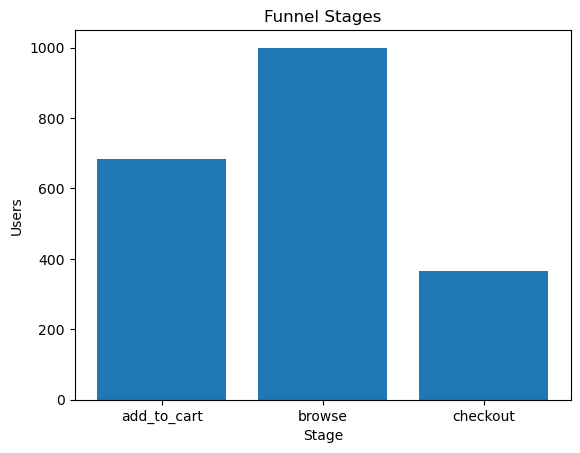

In [14]:
#Plot Funnel
import matplotlib.pyplot as plt

plt.figure()
plt.bar(funnel["event_type"], funnel["session_id"])
plt.title("Funnel Stages")
plt.xlabel("Stage")
plt.ylabel("Users")
plt.show()

In [15]:
#Drop off percentage
funnel = funnel.sort_values(by="session_id", ascending=False)

funnel["drop_off_%"] = funnel["session_id"].pct_change() * -100

funnel

,event_type,session_id,drop_off_%
1,browse,1000,NaN
0,add_to_cart,683,31.70000
2,checkout,364,46.70571


In [16]:
#Heatmap Device vs Stage 
#Merge Data
merged = events_df.merge(sessions, on="session_id") \
                  .merge(users, on="user_id")

In [17]:
#Create Pivot Table
heatmap_data = pd.pivot_table(
    merged,
    values="session_id",
    index="device",
    columns="event_type",
    aggfunc="nunique"
)

heatmap_data

event_type,add_to_cart,browse,checkout
device,,,
desktop,337,486,186
mobile,346,514,178


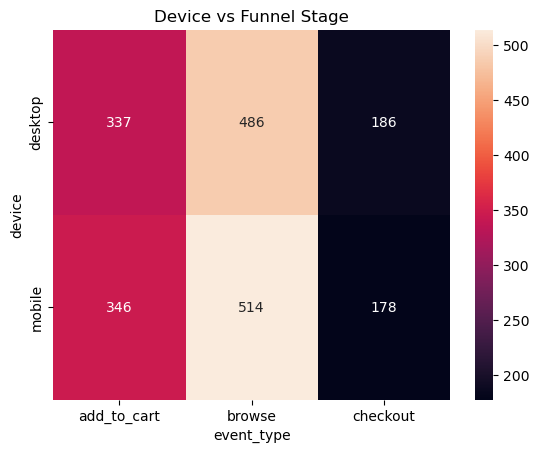

In [18]:
#Plot Heatmap
import seaborn as sns

plt.figure()
sns.heatmap(heatmap_data, annot=True, fmt=".0f")
plt.title("Device vs Funnel Stage")
plt.show()

In [19]:
source_analysis = merged.groupby("source")["session_id"].nunique()
source_analysis

source
ads        349
organic    332
social     319
Name: session_id, dtype: int64